# Rendering

> A set of functions used for all rendering of the grid objects.

In [ ]:
#| default_exp utils.rendering

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from __future__ import annotations


In [ ]:
#| export
import math
import numpy as np
from numpy.typing import NDArray as ndarray
from typing import Callable



In [ ]:
#| export
FilterFunction = Callable[[float, float], bool]
White = np.array([255, 255, 255])


## Generic Rendering Functions

In [ ]:
#| hide
img = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
img.shape

(64, 64, 3)

In [ ]:
#| hide
factor = 2

In [ ]:
#| hide
img = img.reshape(
        [img.shape[0] // factor, factor, img.shape[1] // factor, factor, 3]
    )
img.shape

(32, 2, 32, 2, 3)

In [ ]:
#| hide
img = img.mean(axis=3).mean(axis=1)

In [ ]:
#| hide
img = np.round(img).astype(np.uint8)
img.shape

(32, 32, 3)

In [ ]:
#| export
def downsample(img: ndarray[np.uint8], factor: int) -> ndarray[np.uint8]:
    """
    Downsample an image along both dimensions by some factor.

    Parameters
    ----------
    img : ndarray[uint8] of shape (height, width, 3)
        The image to downsample
    factor : int
        The factor by which to downsample the image

    Returns
    -------
    img : ndarray[uint8] of shape (height/factor, width/factor, 3)
        The downsampled image
    """
    assert img.shape[0] % factor == 0
    assert img.shape[1] % factor == 0


    img = img.reshape(
        [img.shape[0] // factor, factor, img.shape[1] // factor, factor, 3]
    )
    img = np.round(img
                   .mean(axis=3)
                   .mean(axis=1))

    return img.astype(np.uint8)


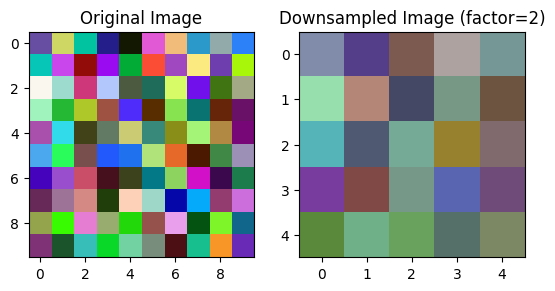

In [ ]:
#| hide
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2)
img = np.random.randint(0, 255, (10, 10, 3), dtype=np.uint8)

down_sampled_img = downsample(img, 2)
ax[0].imshow(img)
ax[0].set_title("Original Image")

ax[1].imshow(down_sampled_img)  
ax[1].set_title("Downsampled Image (factor=2)")
plt.show()

In [ ]:
#| hide
import numpy as np
factor = 2
grid = np.arange(1, 17).reshape(4, 4)
grid = grid.reshape(
        [grid.shape[0] // factor, factor, grid.shape[1] // factor, factor]
    )
print(grid.mean(axis=3).mean(axis=1))
grid = np.round(grid
                .mean(axis=3)
                .mean(axis=1))

grid = grid.astype(np.uint8)
grid

[[ 3.5  5.5]
 [11.5 13.5]]


array([[ 4,  6],
       [12, 14]], dtype=uint8)

## Higher-order Functions

### Fill Coordinates


This function is essentially a procedural mask filler. It iterates through every pixel in an image and decides whether to paint it a specific color based on a mathematical rule (the fn function). The basic idea is to loop through each pixel, normalize its coordinates to the range [0, 1], and then apply the filter function to determine if it should be colored. If the `filter function` returns True for a given pixel, we set that pixel's color to the specified color. 

In [ ]:
#| export

def fill_coords(
    img: ndarray[np.uint8],
    fn: FilterFunction,
    color: ndarray[np.uint8]) -> ndarray[np.uint8]:
    """
    Fill pixels of an image with coordinates matching a filter function.

    Parameters
    ----------
    img : ndarray[uint8] of shape (height, width, 3)
        The image to fill
    fn : Callable(float, float) -> bool
        The filter function to use for coordinates
    color : ndarray[uint8] of shape (3,)
        RGB color to fill matching coordinates

    Returns
    -------
    img : ndarray[np.uint8] of shape (height, width, 3)
        The updated image
    """
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            yf = (y + 0.5) / img.shape[0]
            xf = (x + 0.5) / img.shape[1]
            if fn(xf, yf):
                img[y, x] = color

    return img


let us exactly what happens inside the loop that normalize the coordinates and applies the filter function:

In [ ]:
#| hide
import numpy as np
import pandas as pd
grid = np.arange(1, 17).reshape(4, 4)
lst = []
old_lst = []
for y in range(grid.shape[0]):
    for x in range(grid.shape[1]):
        yf = (y + 0.5) / grid.shape[0]
        xf = (x + 0.5) / grid.shape[1]
        lst.append((xf, yf))
        old_lst.append((x, y))
all_grid = pd.DataFrame(lst, columns=["xf", "yf"])
all_grid["old_x"] = [x for x, y in old_lst]
all_grid["old_y"] = [y for x, y in old_lst]
all_grid["value"] = grid.flatten()
all_grid

,xf,yf,old_x,old_y,value
0,0.125,0.125,0,0,1
1,0.375,0.125,1,0,2
2,0.625,0.125,2,0,3
3,0.875,0.125,3,0,4
4,0.125,0.375,0,1,5
5,0.375,0.375,1,1,6
6,0.625,0.375,2,1,7
7,0.875,0.375,3,1,8
8,0.125,0.625,0,2,9
9,0.375,0.625,1,2,10


For example, given the following completely black image:

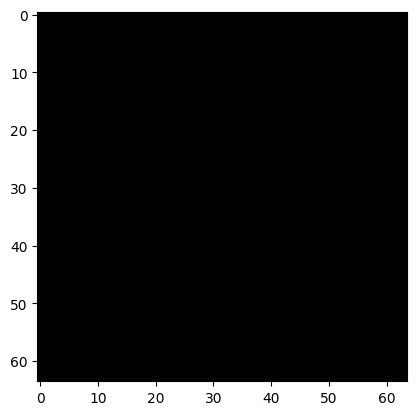

In [ ]:
#| hide
import matplotlib.pyplot as plt
import numpy as np
img = np.zeros((64, 64, 3), dtype=np.uint8)
plt.imshow(img)
plt.show()

And if we have the following filter function that defines a circular region (or a square region):

In [ ]:
#| hide
def circle_fn(x, y):
    # Center at (0.5, 0.5), Radius of 0.2
    return (x - 0.5)**2 + (y - 0.5)**2 < 0.2**2
def is_center_square(xf, yf):
    # Returns True if the coordinate is within the middle 20% of the image
    return 0.4 < xf < 0.6 and 0.4 < yf < 0.6

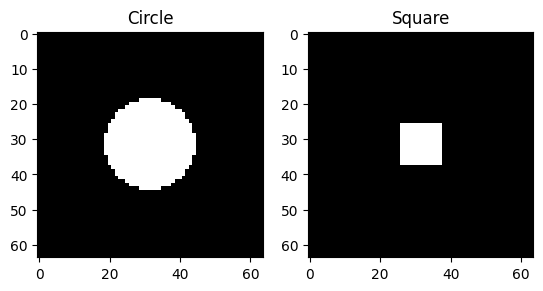

In [ ]:
#| hide
fig, ax = plt.subplots(1, 2)
img = np.zeros((64, 64, 3), dtype=np.uint8)
copied_img = img.copy()
filled_img = fill_coords(img, circle_fn, White)
ax[0].imshow(filled_img)
ax[0].set_title("Circle")

filled_img = fill_coords(copied_img, is_center_square, White)
ax[1].imshow(filled_img)
ax[1].set_title("Square")
plt.show()

### Rotate Function

In [ ]:
#| export

def rotate_fn(
        fin: FilterFunction,
        cx: float,
        cy: float,
        theta: float) -> FilterFunction:
    """
    Rotate a coordinate filter function around a center point by some angle.

    Parameters
    ----------
    fin : Callable(float, float) -> bool
        The filter function to rotate
    cx : float
        The x-coordinate of the center of rotation
    cy : float
        The y-coordinate of the center of rotation
    theta : float
        The angle by which to rotate the filter function (in radians)

    Returns
    -------
    fout : Callable(float, float) -> bool
        The rotated filter function
    """
    def fout(x, y):
        x = x - cx
        y = y - cy

        x2 = cx + x * math.cos(-theta) - y * math.sin(-theta)
        y2 = cy + y * math.cos(-theta) + x * math.sin(-theta)

        return fin(x2, y2)

    return fout


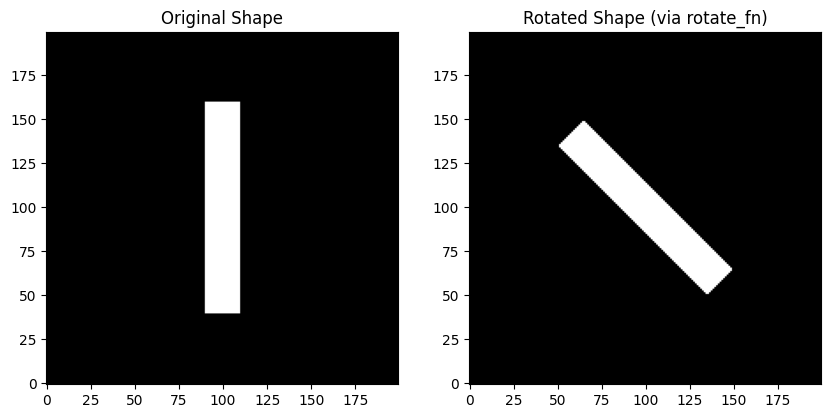

In [ ]:
#| hide
import numpy as np
import matplotlib.pyplot as plt
import math

# -------- Original filter function (a vertical bar) --------
def fin(x, y):
    return (0.45 < x < 0.55) and (0.2 < y < 0.8)

# -------- Create rotated function --------
theta = math.pi / 4  # 45 degrees
cx, cy = 0.5, 0.5

f_rot = rotate_fn(fin, cx, cy, theta)

# -------- Generate images --------
img = np.zeros((200, 200, 3), dtype=np.uint8)
copied_img = img.copy()
img_original = fill_coords(img, fin, White)
img_rotated = fill_coords(copied_img, f_rot, White)


# -------- Plot results --------
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img_original, origin='lower')
axs[0].set_title("Original Shape")

axs[1].imshow(img_rotated, origin='lower')
axs[1].set_title("Rotated Shape (via rotate_fn)")

# for ax in axs:
#     ax.set_xticks([])
#     ax.set_yticks([])

plt.show()

In [ ]:
#| hide
# Pick a point in output space
x, y = 0.7, 0.5

# Apply inverse rotation manually
x_shift = x - cx
y_shift = y - cy

x2 = cx + x_shift * math.cos(-theta) - y_shift * math.sin(-theta)
y2 = cy + y_shift * math.cos(-theta) + x_shift * math.sin(-theta)

print(f"Original query point: ({x:.3f}, {y:.3f})")
print(f"Mapped point (into fin): ({x2:.3f}, {y2:.3f})")
print(f"fin(x2, y2) = {fin(x2, y2)}")

Original query point: (0.700, 0.500)
Mapped point (into fin): (0.641, 0.359)
fin(x2, y2) = False


### Point-in-line

In [ ]:
#| export

def point_in_line(
    x0: float, y0: float, x1: float, y1: float, r: float) -> FilterFunction:
    """
    Return a filter function that returns True for points within distance r
    from the line between (x0, y0) and (x1, y1).

    Parameters
    ----------
    x0 : float
        The x-coordinate of the line start point
    y0 : float
        The y-coordinate of the line start point
    x1 : float
        The x-coordinate of the line end point
    y1 : float
        The y-coordinate of the line end point
    r : float
        Maximum distance from the line

    Returns
    -------
    fn : Callable(float, float) -> bool
        Filter function
    """
    p0 = np.array([x0, y0], dtype=np.float32)
    p1 = np.array([x1, y1], dtype=np.float32)
    dir = p1 - p0
    dist = np.linalg.norm(dir)
    dir = dir / dist

    xmin = min(x0, x1) - r
    xmax = max(x0, x1) + r
    ymin = min(y0, y1) - r
    ymax = max(y0, y1) + r

    def fn(x, y):
        # Fast, early escape test
        if x < xmin or x > xmax or y < ymin or y > ymax:
            return False

        q = np.array([x, y])
        pq = q - p0

        # Closest point on line
        a = np.dot(pq, dir)
        a = np.clip(a, 0, dist)
        p = p0 + a * dir

        dist_to_line = np.linalg.norm(q - p)
        return dist_to_line <= r

    return fn


In [ ]:
#| export

def point_in_circle(cx: float, cy: float, r: float) -> FilterFunction:
    """
    Return a filter function that returns True for points within radius r
    from a given point.

    Parameters
    ----------
    cx : float
        The x-coordinate of the circle center
    cy : float
        The y-coordinate of the circle center
    r : float
        The radius of the circle

    Returns
    -------
    fn : Callable(float, float) -> bool
        Filter function
    """
    def fn(x, y):
        return (x - cx) * (x - cx) + (y - cy) * (y - cy) <= r * r

    return fn


In [ ]:
#| export

def point_in_rect(xmin: float, xmax: float, ymin: float, ymax: float) -> FilterFunction:
    """
    Return a filter function that returns True for points within a rectangle.

    Parameters
    ----------
    xmin : float
        The minimum x-coordinate of the rectangle
    xmax : float
        The maximum x-coordinate of the rectangle
    ymin : float
        The minimum y-coordinate of the rectangle
    ymax : float
        The maximum y-coordinate of the rectangle

    Returns
    -------
    fn : Callable(float, float) -> bool
        Filter function
    """
    def fn(x, y):
        return x >= xmin and x <= xmax and y >= ymin and y <= ymax

    return fn


In [ ]:
#| export

def point_in_triangle(
    a: tuple[float, float],
    b: tuple[float, float],
    c: tuple[float, float]) -> FilterFunction:
    """
    Return a filter function that returns True for points within a triangle.

    Parameters
    ----------
    a : tuple[float, float]
        The first vertex of the triangle
    b : tuple[float, float]
        The second vertex of the triangle
    c : tuple[float, float]
        The third vertex of the triangle

    Returns
    -------
    fn : Callable(float, float) -> bool
        Filter function
    """
    a = np.array(a, dtype=np.float32)
    b = np.array(b, dtype=np.float32)
    c = np.array(c, dtype=np.float32)

    def fn(x, y):
        v0 = c - a
        v1 = b - a
        v2 = np.array((x, y)) - a

        # Compute dot products
        dot00 = np.dot(v0, v0)
        dot01 = np.dot(v0, v1)
        dot02 = np.dot(v0, v2)
        dot11 = np.dot(v1, v1)
        dot12 = np.dot(v1, v2)

        # Compute barycentric coordinates
        inv_denom = 1 / (dot00 * dot11 - dot01 * dot01)
        u = (dot11 * dot02 - dot01 * dot12) * inv_denom
        v = (dot00 * dot12 - dot01 * dot02) * inv_denom

        # Check if point is in triangle
        return (u >= 0) and (v >= 0) and (u + v) < 1

    return fn


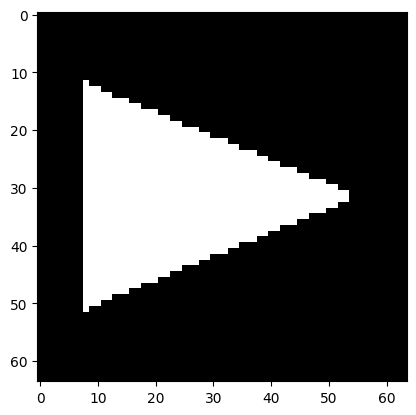

In [ ]:
#| hide
img = np.zeros((64, 64, 3), dtype=np.uint8)
tri_fn = point_in_triangle(
        (0.12, 0.19),
        (0.87, 0.50),
        (0.12, 0.81),
    )

tri_fn = rotate_fn(tri_fn, cx=0.5, cy=0.5, theta=0.5 * np.pi * 0)
fill_coords(img, tri_fn, np.array([255, 255, 255], dtype=np.uint8))

plt.imshow(img)
plt.show()

In [ ]:
#| export

def highlight_img(
    img: ndarray[np.uint8],
    color: ndarray[np.uint8] = White,
    alpha=0.30) -> ndarray[np.uint8]:
    """
    Add highlighting to an image.

    Parameters
    ----------
    img : ndarray[uint8] of shape (height, width, 3)
        The image to highlight
    color : ndarray[uint8] of shape (3,)
        RGB color to use for highlighting
    alpha : float
        The alpha value to use for blending

    Returns
    -------
    img : ndarray[uint8] of shape (height, width, 3)
        The highlighted image
    """
    blend_img = img + alpha * (np.array(color, dtype=np.uint8) - img)
    blend_img = blend_img.clip(0, 255).astype(np.uint8)
    img[:, :, :] = blend_img


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()